### Model Tournament Implementation

In [1]:
# --- Jupyter Cell 1: Setup and Data Loading ---
import numpy as np
import pandas as pd
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from prophet import Prophet

warnings.filterwarnings("ignore")

# Global parameters
HORIZONS = [4, 12, 26] # Define the forecast horizons we want to test
SEASONALITY = 52  # annual seasonality for weekly data

# Load weekly velocity dataset
df = pd.read_csv("Datasets/Extracted_Data/ycrit_weekly_w_mon_copy.csv")

# Convert the 'week' column to datetime format
# This is important so pandas treats it correctly as a time index
df["week"] = pd.to_datetime(df["week"], utc=True)
df = df.set_index("week").sort_index() #Set the 'week' column as the DataFrame index

# Chronological split
train = df.loc["2019-01-01":"2022-12-31"].copy()
test  = df.loc["2023-01-01":"2023-12-31"].copy()

y_train = train["ycrit"] # Extract the target variable 'ycrit' from training data
y_test  = test["ycrit"] # Extract the target variable 'ycrit' from testing data

print(f"Training weeks (2019-2022): {len(y_train)}")
print(f"Testing weeks (2023): {len(y_test)}")
print(df.head())
print(df.tail())

Importing plotly failed. Interactive plots will not work.


Training weeks (2019-2022): 208
Testing weeks (2023): 52
                           ycrit
week                            
2019-01-07 00:00:00+00:00     12
2019-01-14 00:00:00+00:00     70
2019-01-21 00:00:00+00:00     84
2019-01-28 00:00:00+00:00     51
2019-02-04 00:00:00+00:00     39
                           ycrit
week                            
2023-11-27 00:00:00+00:00    216
2023-12-04 00:00:00+00:00    367
2023-12-11 00:00:00+00:00    320
2023-12-18 00:00:00+00:00    450
2023-12-25 00:00:00+00:00    336


### Defined functions for the planned metrics to be used.

In [2]:
# --- Jupyter Cell 2: Evaluation Metrics ---

# Define a helper function to calculate RMSE
# RMSE = Root Mean Squared Error
# It penalises larger forecast mistakes more than MAE does
def rmse(y_true, y_pred):
    # mean_squared_error computes the average squared difference
    # np.sqrt converts it back into the original unit scale
    return np.sqrt(mean_squared_error(y_true, y_pred))


# Define a function to calculate the denominator used in MASE
# MASE compares a model against a baseline seasonal naive forecast
def mase_denom(y_hist: pd.Series, seasonality: int = 52) -> float:
    """
    Compute the in-sample MAE of a seasonal naive forecast.
    In seasonal naive forecasting, each point is predicted by the value
    from one season earlier (for weekly data, one year earlier = 52 weeks).
    """

    # Compare observations from time t with observations from time t-52
    # Example: week 53 is compared with week 1, week 54 with week 2, etc.
    errs = np.abs(y_hist.iloc[seasonality:].values - y_hist.iloc[:-seasonality].values)
    # Return the average absolute seasonal naive error
    return float(np.mean(errs))

def score_block(y_true: np.ndarray, y_pred: np.ndarray, denom: float):
    """
    Scores a multi-step block forecast of length h.
    """
    mae = mean_absolute_error(y_true, y_pred)               # MAE = average absolute difference between actual and predicted values
    r = rmse(y_true, y_pred)                                # RMSE = root mean squared error

    # MASE = MAE divided by the seasonal naive denominator
    # If denominator is zero or missing, return NaN
    mase = mae / denom if denom and denom != 0 else np.nan 

    return mae, r, mase                                     # Return all three metrics as a tuple

# Test the MASE denominator on the training set
den_train = mase_denom(y_train, SEASONALITY)
print("MASE denominator (training set):", den_train)

MASE denominator (training set): 79.12179487179488


### Wrapper functions for Prophet.

In [3]:
# --- Jupyter Cell 3: Model Wrapper Functions ---
def prophet_fit(y_hist: pd.Series) -> Prophet:
    """
        Fit Prophet on a weekly time series.
        Prophet expects a DataFrame with two columns:
        ds = datestamp
        y  = target variable
    """
    dfp = y_hist.reset_index()      # Reset the index so the datetime index becomes a normal column
    dfp.columns = ["ds", "y"]       # Rename columns to the names Prophet expects: 'ds' and 'y'
    dfp["ds"] = dfp["ds"].dt.tz_localize(None)  # Remove timezone information for Prophet compatibility
    # Create the Prophet model
    # yearly_seasonality=True tells Prophet to model annual seasonal patterns
    # weekly_seasonality=False because the data are already weekly, not daily
    # daily_seasonality=False because daily effects are not relevant here
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    
    m.fit(dfp)  # Fit the model to the historical data
    return m    # Return the trained Prophet model

def prophet_forecast(m: Prophet, h: int):
    """
        Forecast the next h weeks using a fitted Prophet model.
        Returns:
        - point forecasts (yhat)
        - lower and upper interval bounds (yhat_lower, yhat_upper)
    """
    # Create a future DataFrame extending h weeks beyond the training data
    future = m.make_future_dataframe(periods=h, freq="W-MON")

    # Keep only the last h rows, which correspond to the future forecast period
    fcst = m.predict(future).tail(h)


    # Return:
    # 1. yhat = forecasted values
    # 2. yhat_lower and yhat_upper = prediction interval bounds
    return fcst["yhat"].values, fcst[["yhat_lower", "yhat_upper"]].values

### Expanding-window backtesting (2019–2022)

In [ ]:
# # --- Jupyter Cell 4: Backtesting Engine ---
# def expanding_window_cv(y: pd.Series, initial_train_size: int = 104, step: int = 4):
#     """
#     Perform expanding-window backtesting on the 2019-2022 series.

#     For each forecast origin:
#     1. Fit models on all available data up to that point
#     2. Forecast the next h weeks for h in {4, 12, 26}
#     3. Compare forecasts with actual values
#     4. Store MAE, RMSE, and MASE

#     Parameters:
#     - y: time series to backtest
#     - initial_train_size: first number of observations used before forecasting starts
#     - step: number of weeks by which the forecast origin advances

#     Returns:
#     - DataFrame of average metrics by model and horizon
#     """
#     # Store results for each model and each forecast horizon
#     results = {m: {h: [] for h in HORIZONS} for m in ["naive", "ets", "sarima", "prophet"]}

#     # Loop through each expanding forecast origin
#     for origin in range(initial_train_size, len(y) - max(HORIZONS) + 1, step):
#         print(f"Backtest origin: {origin}/{len(y)}")

#         y_hist = y.iloc[:origin]                        # Historical data available up to the current forecast origin
#         denom = mase_denom(y_hist, SEASONALITY)         # Compute the MASE denominator using only the historical data

#         # Fit models once per origin
#         p_model = prophet_fit(y_hist)
#         sar_model = auto_arima(
#             y_hist, seasonal=True, m=SEASONALITY,
#             trace=False, error_action="ignore", suppress_warnings=True,
#                 max_p=3, max_q=2, max_P=1, max_Q=1, max_d=2, max_D=1
#         )
#         ets_model = ExponentialSmoothing(
#             y_hist, trend="add", seasonal="add", seasonal_periods=SEASONALITY
#         ).fit(optimized=True)

#         # Evaluate all forecast horizons using the fitted models
#         for h in HORIZONS:
#             # The true observed values for the next h weeks
#             y_true = y.iloc[origin:origin+h].values

#             # Seasonal naive
#             # Predict each point using the value from 52 weeks earlier
#             y_naive = y.shift(SEASONALITY).iloc[origin:origin+h].values
#             results["naive"][h].append(score_block(y_true, y_naive, denom))

#             # ETS
#             y_ets = ets_model.forecast(h).values
#             results["ets"][h].append(score_block(y_true, y_ets, denom))

#             # SARIMA
#             y_sar = sar_model.predict(n_periods=h)
#             results["sarima"][h].append(score_block(y_true, y_sar, denom))

#             # Prophet
#             y_pro, _ = prophet_forecast(p_model, h)
#             results["prophet"][h].append(score_block(y_true, y_pro, denom))

#     # Convert collected results into a summary table
#     rows = []
#     for model, by_h in results.items():
#         for h, triples in by_h.items():
#             arr = np.array(triples)
#             rows.append([
#                 model, h,
#                 arr[:, 0].mean(),   # Average MAE
#                 arr[:, 1].mean(),   # Average RMSE
#                 arr[:, 2].mean()    # Average MASE
#             ])

#     return pd.DataFrame(rows, columns=["model", "horizon_weeks", "MAE", "RMSE", "MASE"])

# # Run expanding-window backtesting
# print("Running expanding-window backtest...")
# cv_summary = expanding_window_cv(y_train, initial_train_size=104, step=4)

# print("\n--- BACKTEST RESULTS (2019-2022) ---")

# # Sort results for easier interpretation
# cv_summary = cv_summary.sort_values(["horizon_weeks", "MAE"])
# print(cv_summary.to_string(index=False))

### 4.9.1 One-shot (“train-once”) 2023 evaluation


In [4]:
# # --- Jupyter Cell 4: One-shot (“train-once”) 2023 evaluation ---
print("Starting one-shot 2023 holdout evaluation...")

# Seasonal naive forecast:
# each 2023 week is predicted using the same week from 2022
naive_2023 = df["ycrit"].shift(SEASONALITY).loc[y_test.index].values

print("Seasonal naive forecast completed.")
print("Length of naive forecast:", len(naive_2023))
print("First 5 naive forecast values:", naive_2023[:5])

Starting one-shot 2023 holdout evaluation...
Seasonal naive forecast completed.
Length of naive forecast: 52
First 5 naive forecast values: [149. 162. 342. 220. 268.]


In [5]:
print("Fitting ETS model on 2019-2022 training data...")

ets_model_full = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=SEASONALITY
).fit(optimized=True)

print("ETS model fitted successfully.")

ets_2023 = ets_model_full.forecast(len(y_test)).values

print("ETS forecast for 2023 completed.")
print("Length of ETS forecast:", len(ets_2023))
print("First 5 ETS forecast values:", ets_2023[:5])

Fitting ETS model on 2019-2022 training data...
ETS model fitted successfully.
ETS forecast for 2023 completed.
Length of ETS forecast: 52
First 5 ETS forecast values: [221.46697012 242.48117152 333.92863129 270.18214872 268.6694688 ]


In [6]:
print("Fitting SARIMA model on 2019-2022 training data...")
print("This step may take a while if not limited...")

sarima_model_full = auto_arima(
    y_train,
    seasonal=True,  
    m=SEASONALITY,              # SEASONALITY = 52
    trace=True,                 # show search progress
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,              # keep search more manageable
    max_p=3,                    # limit AR order to 3
    max_q=2,                    # limit MA order to 2
    max_P=1,                    # limit seasonal AR order to 1
    max_Q=1,                    # limit seasonal MA order to 1
    max_d=2,                    # limit differencing order to 2
    max_D=1                     # limit seasonal differencing order to 1
)

print("SARIMA model fitted successfully.")

sarima_2023, sarima_2023_int = sarima_model_full.predict(
    n_periods=len(y_test),
    return_conf_int=True,
    alpha=0.05
)

print("SARIMA forecast for 2023 completed.")
print("Length of SARIMA forecast:", len(sarima_2023))
print("First 5 SARIMA forecast values:", sarima_2023[:5])

Fitting SARIMA model on 2019-2022 training data...
This step may take a while if not limited...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=inf, Time=13.38 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=2529.630, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=2477.186, Time=2.70 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=inf, Time=3.60 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=2527.673, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=2491.339, Time=0.06 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=2475.893, Time=6.27 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=2481.661, Time=3.10 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=2527.695, Time=4.76 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : AIC=2447.110, Time=9.28 sec
 ARIMA(2,1,0)(0,0,1)[52] intercept   : AIC=2454.327, Time=3.28 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=2450.061, Time=5.20 sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=2461.583, Time=0.12 sec

In [7]:
print("Fitting Prophet model on 2019-2022 training data...")

p_full = prophet_fit(y_train)

print("Prophet model fitted successfully.")

prophet_2023, prophet_2023_int = prophet_forecast(p_full, len(y_test))

print("Prophet forecast for 2023 completed.")
print("Length of Prophet forecast:", len(prophet_2023))
print("First 5 Prophet forecast values:", prophet_2023[:5])

09:28:21 - cmdstanpy - INFO - Chain [1] start processing
09:28:21 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet model on 2019-2022 training data...
Prophet model fitted successfully.
Prophet forecast for 2023 completed.
Length of Prophet forecast: 52
First 5 Prophet forecast values: [295.19858056 256.76324193 253.40123524 280.57869706 307.91724541]


In [8]:
print("Scoring one-shot forecasts...")

# Compute MASE denominator from training data
den = mase_denom(y_train, SEASONALITY)
print("MASE denominator computed:", den)

def score_year(y_true, y_pred, denom):
    mae = mean_absolute_error(y_true, y_pred)
    r = rmse(y_true, y_pred)
    mase = mae / denom if denom else np.nan
    return mae, r, mase

scores_one_shot = pd.DataFrame([
    ["Seasonal Naive", *score_year(y_test.values, naive_2023, den)],
    ["ETS",            *score_year(y_test.values, ets_2023, den)],
    ["SARIMA",         *score_year(y_test.values, sarima_2023, den)],
    ["Prophet",        *score_year(y_test.values, prophet_2023, den)],
], columns=["Model", "MAE_2023", "RMSE_2023", "MASE_2023"])

print("One-shot scoring complete.")
print("\n--- ONE-SHOT 2023 HOLDOUT RESULTS ---")
display(scores_one_shot.sort_values("MAE_2023"))

Scoring one-shot forecasts...
MASE denominator computed: 79.12179487179488
One-shot scoring complete.

--- ONE-SHOT 2023 HOLDOUT RESULTS ---


,Model,MAE_2023,RMSE_2023,MASE_2023
1,ETS,57.136368,68.293842,0.722132
2,SARIMA,59.144649,70.311838,0.747514
0,Seasonal Naive,68.942308,87.818979,0.871344
3,Prophet,69.786744,80.768991,0.882017


### Visualization of forcasts:

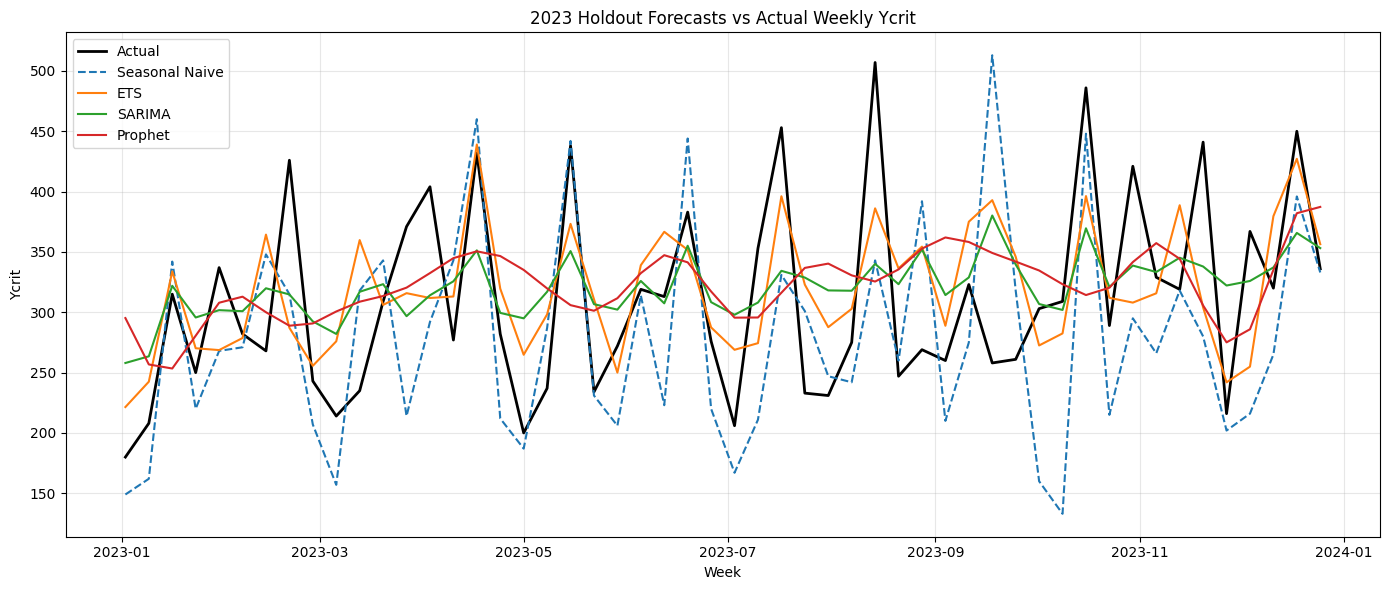

In [9]:
# --- Jupyter Cell: Holdout Forecast Visualisations ---

import matplotlib.pyplot as plt

# Create a DataFrame containing actual and forecast values for 2023
plot_df = pd.DataFrame({
    "Actual": y_test.values,
    "Seasonal Naive": naive_2023,
    "ETS": ets_2023,
    "SARIMA": sarima_2023,
    "Prophet": prophet_2023
}, index=y_test.index)

# ---------------------------------------
# Plot 1: All one-shot forecasts vs actual
# ---------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(plot_df.index, plot_df["Actual"], label="Actual", color="black", linewidth=2)
plt.plot(plot_df.index, plot_df["Seasonal Naive"], label="Seasonal Naive", linestyle="--")
plt.plot(plot_df.index, plot_df["ETS"], label="ETS")
plt.plot(plot_df.index, plot_df["SARIMA"], label="SARIMA")
plt.plot(plot_df.index, plot_df["Prophet"], label="Prophet")

plt.title("2023 Holdout Forecasts vs Actual Weekly Ycrit")
plt.xlabel("Week")
plt.ylabel("Ycrit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

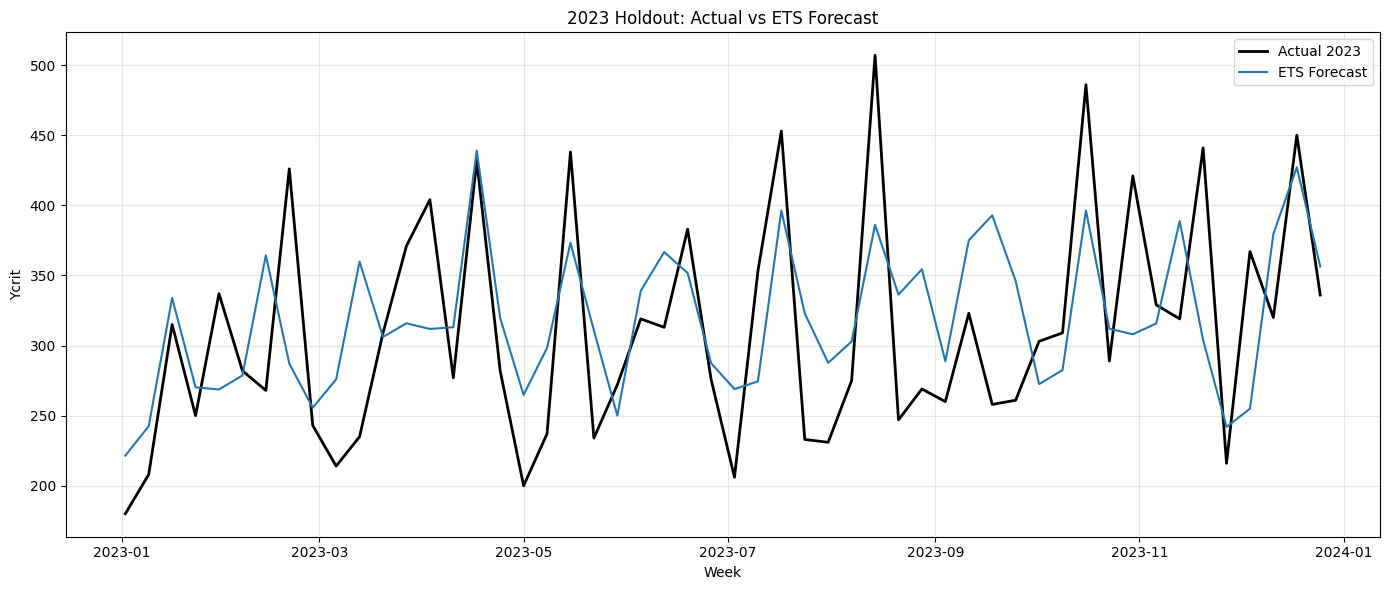

In [13]:
# Sort models by MAE (ascending) and extract the name of the best performing model
best_model_name = scores_one_shot.sort_values("MAE_2023").iloc[0]["Model"]

# Match the best model name to its corresponding forecast array
if best_model_name == "Seasonal Naive":
    best_forecast = naive_2023
elif best_model_name == "ETS":
    best_forecast = ets_2023
elif best_model_name == "SARIMA":
    best_forecast = sarima_2023
elif best_model_name == "Prophet":
    best_forecast = prophet_2023

# ---------------------------------------
# Plot 2: Best model vs actual
# ---------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Actual 2023", color="black", linewidth=2)
plt.plot(y_test.index, best_forecast, label=f"{best_model_name} Forecast", color="tab:blue")

plt.title(f"2023 Holdout: Actual vs {best_model_name} Forecast")
plt.xlabel("Week")
plt.ylabel("Ycrit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

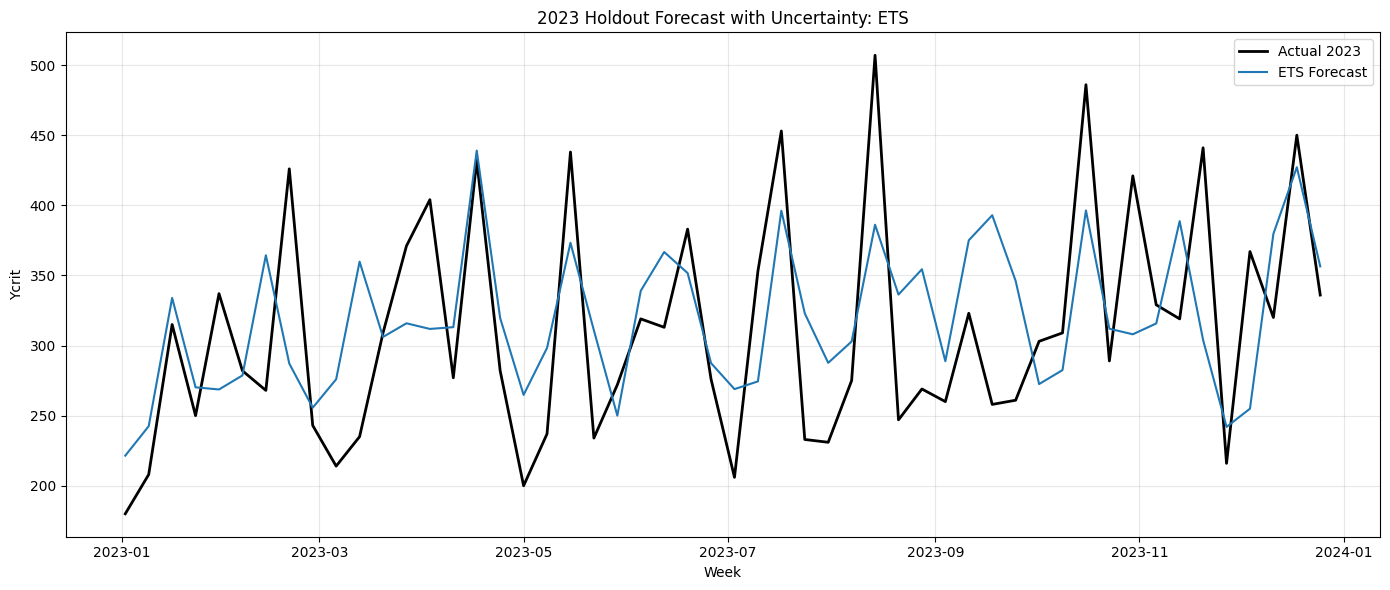

In [14]:
# ---------------------------------------
# Plot 3: Best model with interval, where available
# ---------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Actual 2023", color="black", linewidth=2)

if best_model_name == "SARIMA":
    plt.plot(y_test.index, sarima_2023, label="SARIMA Forecast", color="tab:blue")
    plt.fill_between(
        y_test.index,
        sarima_2023_int[:, 0],
        sarima_2023_int[:, 1],
        color="tab:blue",
        alpha=0.2,
        label="95% Interval"
    )

elif best_model_name == "Prophet":
    plt.plot(y_test.index, prophet_2023, label="Prophet Forecast", color="tab:green")
    plt.fill_between(
        y_test.index,
        prophet_2023_int[:, 0],
        prophet_2023_int[:, 1],
        color="tab:green",
        alpha=0.2,
        label="95% Interval"
    )

else:
    plt.plot(y_test.index, best_forecast, label=f"{best_model_name} Forecast", color="tab:blue")

plt.title(f"2023 Holdout Forecast with Uncertainty: {best_model_name}")
plt.xlabel("Week")
plt.ylabel("Ycrit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


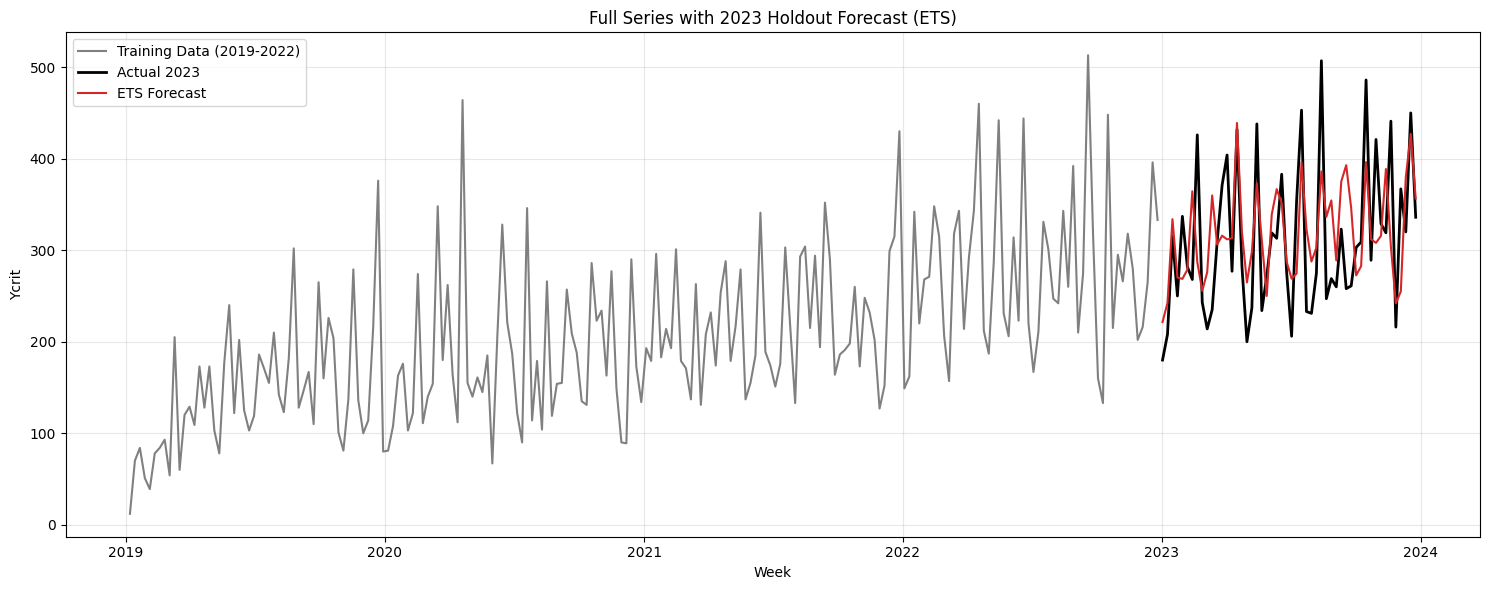

In [15]:
# ---------------------------------------
# Plot 4: Full historical series + holdout forecast
# ---------------------------------------
plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train.values, label="Training Data (2019-2022)", color="gray")
plt.plot(y_test.index, y_test.values, label="Actual 2023", color="black", linewidth=2)
plt.plot(y_test.index, best_forecast, label=f"{best_model_name} Forecast", color="tab:red")

plt.title(f"Full Series with 2023 Holdout Forecast ({best_model_name})")
plt.xlabel("Week")
plt.ylabel("Ycrit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()